## Import Libraries and Set Up Data Paths
This cell imports essential Python libraries for data analysis (`pandas`, `numpy`, and `pathlib`) and configures display options for better readability. It also defines the paths to the raw and processed data directories, and sets up variables for the income and informal economy CSV files. The existence of these files is checked to ensure the required data is available before proceeding.

In [46]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

RAW_DIR = Path("../data/data_raw")
PROCESSED_DIR = Path("../data/data_processed")

income_path = RAW_DIR / "OECD_IDD.csv"      # rename to your exact file names
informal_path = RAW_DIR / "WB_INFECDB.csv"

print("Income path:", income_path, "| Exists:", income_path.exists())
print("Informal path:", informal_path, "| Exists:", informal_path.exists())

Income path: ..\data\data_raw\OECD_IDD.csv | Exists: True
Informal path: ..\data\data_raw\WB_INFECDB.csv | Exists: True


<h1>Load Raw Data</h1>
<h2>This section loads the raw CSV files for income inequality and informal economy indicators for South Africa. 
It uses a robust loader to handle encoding issues and checks that the files exist before proceeding.</h2>

In [47]:
def safe_read_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}. Put the CSV in data/data_raw/")
    try:
        # low_memory=False avoids mixed dtypes; encoding errors are common in WB files
        df = pd.read_csv(path, low_memory=False, encoding="utf-8")
    except UnicodeDecodeError:
        df = pd.read_csv(path, low_memory=False, encoding="latin-1")
    print(f"Loaded {path.name} with shape {df.shape}")
    return df

df_income_raw = safe_read_csv(income_path)
df_informal_raw = safe_read_csv(informal_path)

print("Income raw sample:")
display(df_income_raw.head(3))
print("Informal raw sample:")
display(df_informal_raw.head(3))

Loaded OECD_IDD.csv with shape (109804, 37)
Loaded WB_INFECDB.csv with shape (46996, 35)
Income raw sample:
Loaded WB_INFECDB.csv with shape (46996, 35)
Income raw sample:


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ_ID,FREQ_NAME,REF_AREA_ID,REF_AREA_NAME,INDICATOR_ID,INDICATOR_NAME,SEX_ID,SEX_NAME,AGE_ID,AGE_NAME,URBANISATION_ID,URBANISATION_NAME,UNIT_MEASURE_ID,UNIT_MEASURE_NAME,COMP_BREAKDOWN_1_ID,COMP_BREAKDOWN_1_NAME,COMP_BREAKDOWN_2_ID,COMP_BREAKDOWN_2_NAME,COMP_BREAKDOWN_3_ID,COMP_BREAKDOWN_3_NAME,TIME_PERIOD,OBS_VALUE,DATABASE_ID_ID,DATABASE_ID_NAME,UNIT_MULT_ID,UNIT_MULT_NAME,UNIT_TYPE_ID,UNIT_TYPE_NAME,TIME_FORMAT_ID,TIME_FORMAT_NAME,OBS_STATUS_ID,OBS_STATUS_NAME,OBS_CONF_ID,OBS_CONF_NAME
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,TUR,Turkiye,OECD_IDD_AG_S_METH2011,Age group share (Income definition until 2011),_T,Total,Y41T50,41 to 50 years old,_T,Total,PT_POP,Percentage of population,_Z,Not Applicable,OECD_IDD_DEFINITION_D_CUR,Definition: Current definition (OECD_IDD),_Z,Not Applicable,1987,9.1,OECD_IDD,Income Distribution Database,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,TUR,Turkiye,OECD_IDD_AG_S_METH2011,Age group share (Income definition until 2011),_T,Total,Y41T50,41 to 50 years old,_T,Total,PT_POP,Percentage of population,_Z,Not Applicable,OECD_IDD_DEFINITION_D_CUR,Definition: Current definition (OECD_IDD),_Z,Not Applicable,1994,10.0,OECD_IDD,Income Distribution Database,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,TUR,Turkiye,OECD_IDD_AG_S_METH2011,Age group share (Income definition until 2011),_T,Total,Y41T50,41 to 50 years old,_T,Total,PT_POP,Percentage of population,_Z,Not Applicable,OECD_IDD_DEFINITION_D_CUR,Definition: Current definition (OECD_IDD),_Z,Not Applicable,2004,12.5,OECD_IDD,Income Distribution Database,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public


Informal raw sample:


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,SEX_LABEL,AGE,AGE_LABEL,URBANISATION,URBANISATION_LABEL,UNIT_MEASURE,UNIT_MEASURE_LABEL,COMP_BREAKDOWN_1,COMP_BREAKDOWN_1_LABEL,COMP_BREAKDOWN_2,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3,COMP_BREAKDOWN_3_LABEL,TIME_PERIOD,OBS_VALUE,DATABASE_ID,DATABASE_ID_LABEL,UNIT_MULT,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ALB,Albania,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,Total,_T,All age ranges or no breakdown by age,_T,Total,PT,Percentage,_Z,Not Applicable,_Z,Not Applicable,_Z,Not Applicable,1990,37.674255,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,DZA,Algeria,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,Total,_T,All age ranges or no breakdown by age,_T,Total,PT,Percentage,_Z,Not Applicable,_Z,Not Applicable,_Z,Not Applicable,1990,31.055113,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AGO,Angola,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,Total,_T,All age ranges or no breakdown by age,_T,Total,PT,Percentage,_Z,Not Applicable,_Z,Not Applicable,_Z,Not Applicable,1990,43.281193,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public


<h1>Inspect Raw DataFrames <h1>
<h2>This step provides a detailed overview of the loaded datasets, including their shapes, column names, data types, missing values, and sample rows. This helps us understand the structure and quality of the data before cleaning and selecting relevant columns.</h2>

In [48]:
def quick_inspect(name, df: pd.DataFrame):
    print(f"=== {name} | shape={df.shape} ===")
    print("Columns:", list(df.columns))
    print("\nDtypes:")
    print(df.dtypes)
    print("\nMissing values (top 20):")
    print(df.isna().sum().sort_values(ascending=False).head(20))
    print("\nSample rows:")
    display(df.head(5))
    print("-" * 80)
    if df.empty:
        print(f"Warning: {name} DataFrame is empty after loading!")

quick_inspect("Income Distribution (raw)", df_income_raw)
quick_inspect("Informal Economy (raw)", df_informal_raw)

=== Income Distribution (raw) | shape=(109804, 37) ===
Columns: ['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ_ID', 'FREQ_NAME', 'REF_AREA_ID', 'REF_AREA_NAME', 'INDICATOR_ID', 'INDICATOR_NAME', 'SEX_ID', 'SEX_NAME', 'AGE_ID', 'AGE_NAME', 'URBANISATION_ID', 'URBANISATION_NAME', 'UNIT_MEASURE_ID', 'UNIT_MEASURE_NAME', 'COMP_BREAKDOWN_1_ID', 'COMP_BREAKDOWN_1_NAME', 'COMP_BREAKDOWN_2_ID', 'COMP_BREAKDOWN_2_NAME', 'COMP_BREAKDOWN_3_ID', 'COMP_BREAKDOWN_3_NAME', 'TIME_PERIOD', 'OBS_VALUE', 'DATABASE_ID_ID', 'DATABASE_ID_NAME', 'UNIT_MULT_ID', 'UNIT_MULT_NAME', 'UNIT_TYPE_ID', 'UNIT_TYPE_NAME', 'TIME_FORMAT_ID', 'TIME_FORMAT_NAME', 'OBS_STATUS_ID', 'OBS_STATUS_NAME', 'OBS_CONF_ID', 'OBS_CONF_NAME']

Dtypes:
STRUCTURE                 object
STRUCTURE_ID              object
ACTION                    object
FREQ_ID                   object
FREQ_NAME                 object
REF_AREA_ID               object
REF_AREA_NAME             object
INDICATOR_ID              object
INDICATOR_NAME           

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ_ID,FREQ_NAME,REF_AREA_ID,REF_AREA_NAME,INDICATOR_ID,INDICATOR_NAME,SEX_ID,SEX_NAME,AGE_ID,AGE_NAME,URBANISATION_ID,URBANISATION_NAME,UNIT_MEASURE_ID,UNIT_MEASURE_NAME,COMP_BREAKDOWN_1_ID,COMP_BREAKDOWN_1_NAME,COMP_BREAKDOWN_2_ID,COMP_BREAKDOWN_2_NAME,COMP_BREAKDOWN_3_ID,COMP_BREAKDOWN_3_NAME,TIME_PERIOD,OBS_VALUE,DATABASE_ID_ID,DATABASE_ID_NAME,UNIT_MULT_ID,UNIT_MULT_NAME,UNIT_TYPE_ID,UNIT_TYPE_NAME,TIME_FORMAT_ID,TIME_FORMAT_NAME,OBS_STATUS_ID,OBS_STATUS_NAME,OBS_CONF_ID,OBS_CONF_NAME
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,TUR,Turkiye,OECD_IDD_AG_S_METH2011,Age group share (Income definition until 2011),_T,Total,Y41T50,41 to 50 years old,_T,Total,PT_POP,Percentage of population,_Z,Not Applicable,OECD_IDD_DEFINITION_D_CUR,Definition: Current definition (OECD_IDD),_Z,Not Applicable,1987,9.1,OECD_IDD,Income Distribution Database,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,TUR,Turkiye,OECD_IDD_AG_S_METH2011,Age group share (Income definition until 2011),_T,Total,Y41T50,41 to 50 years old,_T,Total,PT_POP,Percentage of population,_Z,Not Applicable,OECD_IDD_DEFINITION_D_CUR,Definition: Current definition (OECD_IDD),_Z,Not Applicable,1994,10.0,OECD_IDD,Income Distribution Database,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,TUR,Turkiye,OECD_IDD_AG_S_METH2011,Age group share (Income definition until 2011),_T,Total,Y41T50,41 to 50 years old,_T,Total,PT_POP,Percentage of population,_Z,Not Applicable,OECD_IDD_DEFINITION_D_CUR,Definition: Current definition (OECD_IDD),_Z,Not Applicable,2004,12.5,OECD_IDD,Income Distribution Database,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,TUR,Turkiye,OECD_IDD_AG_S_METH2011,Age group share (Income definition until 2011),_T,Total,Y41T50,41 to 50 years old,_T,Total,PT_POP,Percentage of population,_Z,Not Applicable,OECD_IDD_DEFINITION_D_CUR,Definition: Current definition (OECD_IDD),_Z,Not Applicable,2007,12.4,OECD_IDD,Income Distribution Database,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,TUR,Turkiye,OECD_IDD_AG_S_METH2011,Age group share (Income definition until 2011),_T,Total,Y41T50,41 to 50 years old,_T,Total,PT_POP,Percentage of population,_Z,Not Applicable,OECD_IDD_DEFINITION_D_CUR,Definition: Current definition (OECD_IDD),_Z,Not Applicable,2009,12.6,OECD_IDD,Income Distribution Database,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public


--------------------------------------------------------------------------------
=== Informal Economy (raw) | shape=(46996, 35) ===
Columns: ['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA', 'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL', 'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL', 'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3', 'COMP_BREAKDOWN_3_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'UNIT_MULT', 'UNIT_MULT_LABEL', 'UNIT_TYPE', 'UNIT_TYPE_LABEL', 'OBS_STATUS', 'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL']

Dtypes:
STRUCTURE                  object
STRUCTURE_ID               object
ACTION                     object
FREQ                       object
FREQ_LABEL                 object
REF_AREA                   object
REF_AREA_LABEL             object
INDICATOR                  object
INDICATO

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,SEX_LABEL,AGE,AGE_LABEL,URBANISATION,URBANISATION_LABEL,UNIT_MEASURE,UNIT_MEASURE_LABEL,COMP_BREAKDOWN_1,COMP_BREAKDOWN_1_LABEL,COMP_BREAKDOWN_2,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3,COMP_BREAKDOWN_3_LABEL,TIME_PERIOD,OBS_VALUE,DATABASE_ID,DATABASE_ID_LABEL,UNIT_MULT,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ALB,Albania,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,Total,_T,All age ranges or no breakdown by age,_T,Total,PT,Percentage,_Z,Not Applicable,_Z,Not Applicable,_Z,Not Applicable,1990,37.674255,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,DZA,Algeria,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,Total,_T,All age ranges or no breakdown by age,_T,Total,PT,Percentage,_Z,Not Applicable,_Z,Not Applicable,_Z,Not Applicable,1990,31.055113,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AGO,Angola,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,Total,_T,All age ranges or no breakdown by age,_T,Total,PT,Percentage,_Z,Not Applicable,_Z,Not Applicable,_Z,Not Applicable,1990,43.281193,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ARG,Argentina,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,Total,_T,All age ranges or no breakdown by age,_T,Total,PT,Percentage,_Z,Not Applicable,_Z,Not Applicable,_Z,Not Applicable,1990,23.974760,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ARM,Armenia,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,Total,_T,All age ranges or no breakdown by age,_T,Total,PT,Percentage,_Z,Not Applicable,_Z,Not Applicable,_Z,Not Applicable,1990,43.777969,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public


--------------------------------------------------------------------------------


<h1>Normalize and Filter Data for South Africa<h1>
<h2>This step standardizes column names, converts data types, and filters both datasets to include only records for South Africa. It ensures the income inequality and informal economy data are in a consistent format, ready for merging and analysis.</h2>

In [49]:
def detect_col(candidates, cols):
    hit = [c for c in candidates if c in cols]
    return hit[0] if hit else None

def normalize_wb(df: pd.DataFrame, value_name: str) -> pd.DataFrame:
    cols = set(df.columns)

    year_col = detect_col(["TIME_PERIOD","Year","year","REF_DATE"], cols)
    val_col  = detect_col(["OBS_VALUE","Value","value","OBS_VALUE_NUMERIC"], cols)

    # country label/code (we'll keep either one that exists)
    area_label = detect_col(["REF_AREA_LABEL","Country Name","country","Location"], cols)
    area_code  = detect_col(["REF_AREA","Country Code","REF_AREA_CODE","ISO3"], cols)

    if not year_col or not val_col:
        raise ValueError(
            f"Could not find year/value columns. "
            f"Found year={year_col}, value={val_col}. "
            f"Available columns: {list(df.columns)}"
        )

    keep = [c for c in [year_col, val_col, area_label, area_code] if c]
    slim = df[keep].copy()

    # standardize names
    rename_map = {year_col: "year", val_col: value_name}
    if area_label: rename_map[area_label] = "country"
    if area_code:  rename_map[area_code]  = "country_code"
    slim.rename(columns=rename_map, inplace=True)

    # types
    slim["year"] = pd.to_numeric(slim["year"], errors="coerce").astype("Int64")
    slim[value_name] = pd.to_numeric(slim[value_name], errors="coerce")

    # keep only South Africa (by label or ISO3 code ZAF)
    if "country" in slim.columns:
        slim = slim[(slim["country"]=="South Africa") | (slim.get("country_code","")=="ZAF")]
    elif "country_code" in slim.columns:
        slim = slim[slim["country_code"]=="ZAF"]

    # drop all-null years/values
    slim = slim.dropna(subset=["year", value_name])

    # de-duplicate (some WB extracts repeat rows across series)
    slim = slim.drop_duplicates(subset=["year", value_name])

    return slim.sort_values("year").reset_index(drop=True)

df_income = normalize_wb(df_income_raw, value_name="gini_index")
df_informal = normalize_wb(df_informal_raw, value_name="informal_employment")

quick_inspect("Income Distribution (normalized)", df_income)
quick_inspect("Informal Economy (normalized)", df_informal)

=== Income Distribution (normalized) | shape=(62064, 2) ===
Columns: ['year', 'gini_index']

Dtypes:
year            Int64
gini_index    float64
dtype: object

Missing values (top 20):
year          0
gini_index    0
dtype: int64

Sample rows:
year          0
gini_index    0
dtype: int64

Sample rows:


,year,gini_index
0,1974,0.43
1,1974,6615000.00
2,1974,21.00
3,1974,18.00
4,1974,14.90


--------------------------------------------------------------------------------
=== Informal Economy (normalized) | shape=(132, 4) ===
Columns: ['year', 'informal_employment', 'country', 'country_code']

Dtypes:
year                     Int64
informal_employment    float64
country                 object
country_code            object
dtype: object

Missing values (top 20):
year                   0
informal_employment    0
country                0
country_code           0
dtype: int64

Sample rows:


,year,informal_employment,country,country_code
0,1990,25.770441,South Africa,ZAF
1,1991,25.884352,South Africa,ZAF
2,1992,25.912428,South Africa,ZAF
3,1993,25.967556,South Africa,ZAF
4,1993,29.344624,South Africa,ZAF


--------------------------------------------------------------------------------


<h1>Check Year Coverage and Data Availability</h1>
<h2>This step checks the range of years covered by both datasets and identifies the years present in both. It also verifies that the filtered DataFrames are not empty, ensuring the data is ready for merging and analysis.</h2>

In [50]:
years_income = set(df_income["year"].dropna().astype(int))
years_informal = set(df_informal["year"].dropna().astype(int))

print("Income years:", min(years_income, default=None), "→", max(years_income, default=None))
print("Informal years:", min(years_informal, default=None), "→", max(years_informal, default=None))
print("Common years:", sorted(years_income & years_informal)[:10], "...")

assert not df_income.empty, "Income dataset is empty after filtering."
assert not df_informal.empty, "Informal dataset is empty after filtering."

Income years: 1974 → 2023
Informal years: 1990 → 2020
Common years: [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999] ...


<h1>Merge Datasets for Analysis</h1>
<h2>This step merges the normalized income inequality and informal economy datasets on the `year` column, keeping only years present in both. It displays a preview of the merged data and checks for missing values to ensure the dataset is ready for further analysis.</h2>

In [51]:
merged_preview = pd.merge(
    df_informal[["year", "informal_employment"]],
    df_income[["year", "gini_index"]],
    on="year",
    how="inner"
).sort_values("year")

display(merged_preview.head(10))
print("Merged shape:", merged_preview.shape)
print("\nMissing values in merged preview:")
print(merged_preview.isna().sum())

,year,informal_employment,gini_index
0,1990,25.770441,1.370000e+01
1,1990,25.770441,5.162000e+03
2,1990,25.770441,8.300000e-01
3,1990,25.770441,8.000000e+00
4,1990,25.770441,2.701357e+07
5,1990,25.770441,2.720000e-01
6,1990,25.770441,-5.444000e+03
7,1990,25.770441,6.850000e-01
8,1990,25.770441,9.658000e+03
9,1990,25.770441,1.072600e+04


Merged shape: (282596, 3)

Missing values in merged preview:
year                   0
informal_employment    0
gini_index             0
dtype: int64


<h1>Summarize Merged Data</h1>
<h2>This step provides summary statistics and quick insights for the merged dataset, including the range of years covered, and the minimum and maximum values for both the Gini index and informal employment. This helps assess the data distribution and identify any potential issues before analysis.</h2>

In [52]:
display(merged_preview.describe(include="all"))

print("\nQuick insights:")
print(f"- Years covered: {merged_preview['year'].min()} → {merged_preview['year'].max()}")
print(f"- Gini index: min={merged_preview['gini_index'].min():.2f}, max={merged_preview['gini_index'].max():.2f}")
print(f"- Informal employment: min={merged_preview['informal_employment'].min():.2f}, max={merged_preview['informal_employment'].max():.2f}")

,year,informal_employment,gini_index
count,282596.0,282596.000000,2.825960e+05
mean,2011.019165,26.373805,1.430504e+06
std,6.024015,13.233869,1.369455e+07
min,1990.0,0.300000,-6.850000e+06
25%,2007.0,18.700000,3.300000e+00
50%,2011.0,26.730995,1.261500e+03
75%,2016.0,31.700000,2.327000e+04
max,2020.0,95.800000,1.206910e+09



Quick insights:
- Years covered: 1990 → 2020
- Gini index: min=-6850000.00, max=1206910494.00
- Informal employment: min=0.30, max=95.80


<h1>Save Merged Data</h2>
<h2>This step saves the merged dataset to the `data_processed` directory for future analysis and reporting. The directory is created if it does not exist.</h2>

In [53]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
merged_preview.to_csv(PROCESSED_DIR / "merged_preview.csv", index=False)

## Reload and Preview Raw CSVs

This step reloads the original income and informal economy CSV files, displays a preview of each dataset, and prints their shapes. This helps verify the raw data structure before further cleaning and processing.

In [54]:
# Load CSVs
income_df = pd.read_csv(income_path)
informal_df = pd.read_csv(informal_path)

# Preview
print("Income dataset preview:")
display(income_df.head())

print("\nInformal economy dataset preview:")
display(informal_df.head())

# Quick shape
print("Income dataset shape:", income_df.shape)
print("Informal economy dataset shape:", informal_df.shape)

Income dataset preview:


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ_ID,FREQ_NAME,REF_AREA_ID,REF_AREA_NAME,INDICATOR_ID,INDICATOR_NAME,SEX_ID,SEX_NAME,AGE_ID,AGE_NAME,URBANISATION_ID,URBANISATION_NAME,UNIT_MEASURE_ID,UNIT_MEASURE_NAME,COMP_BREAKDOWN_1_ID,COMP_BREAKDOWN_1_NAME,COMP_BREAKDOWN_2_ID,COMP_BREAKDOWN_2_NAME,COMP_BREAKDOWN_3_ID,COMP_BREAKDOWN_3_NAME,TIME_PERIOD,OBS_VALUE,DATABASE_ID_ID,DATABASE_ID_NAME,UNIT_MULT_ID,UNIT_MULT_NAME,UNIT_TYPE_ID,UNIT_TYPE_NAME,TIME_FORMAT_ID,TIME_FORMAT_NAME,OBS_STATUS_ID,OBS_STATUS_NAME,OBS_CONF_ID,OBS_CONF_NAME
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,TUR,Turkiye,OECD_IDD_AG_S_METH2011,Age group share (Income definition until 2011),_T,Total,Y41T50,41 to 50 years old,_T,Total,PT_POP,Percentage of population,_Z,Not Applicable,OECD_IDD_DEFINITION_D_CUR,Definition: Current definition (OECD_IDD),_Z,Not Applicable,1987,9.1,OECD_IDD,Income Distribution Database,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,TUR,Turkiye,OECD_IDD_AG_S_METH2011,Age group share (Income definition until 2011),_T,Total,Y41T50,41 to 50 years old,_T,Total,PT_POP,Percentage of population,_Z,Not Applicable,OECD_IDD_DEFINITION_D_CUR,Definition: Current definition (OECD_IDD),_Z,Not Applicable,1994,10.0,OECD_IDD,Income Distribution Database,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,TUR,Turkiye,OECD_IDD_AG_S_METH2011,Age group share (Income definition until 2011),_T,Total,Y41T50,41 to 50 years old,_T,Total,PT_POP,Percentage of population,_Z,Not Applicable,OECD_IDD_DEFINITION_D_CUR,Definition: Current definition (OECD_IDD),_Z,Not Applicable,2004,12.5,OECD_IDD,Income Distribution Database,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,TUR,Turkiye,OECD_IDD_AG_S_METH2011,Age group share (Income definition until 2011),_T,Total,Y41T50,41 to 50 years old,_T,Total,PT_POP,Percentage of population,_Z,Not Applicable,OECD_IDD_DEFINITION_D_CUR,Definition: Current definition (OECD_IDD),_Z,Not Applicable,2007,12.4,OECD_IDD,Income Distribution Database,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,TUR,Turkiye,OECD_IDD_AG_S_METH2011,Age group share (Income definition until 2011),_T,Total,Y41T50,41 to 50 years old,_T,Total,PT_POP,Percentage of population,_Z,Not Applicable,OECD_IDD_DEFINITION_D_CUR,Definition: Current definition (OECD_IDD),_Z,Not Applicable,2009,12.6,OECD_IDD,Income Distribution Database,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public



Informal economy dataset preview:


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,SEX_LABEL,AGE,AGE_LABEL,URBANISATION,URBANISATION_LABEL,UNIT_MEASURE,UNIT_MEASURE_LABEL,COMP_BREAKDOWN_1,COMP_BREAKDOWN_1_LABEL,COMP_BREAKDOWN_2,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3,COMP_BREAKDOWN_3_LABEL,TIME_PERIOD,OBS_VALUE,DATABASE_ID,DATABASE_ID_LABEL,UNIT_MULT,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ALB,Albania,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,Total,_T,All age ranges or no breakdown by age,_T,Total,PT,Percentage,_Z,Not Applicable,_Z,Not Applicable,_Z,Not Applicable,1990,37.674255,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,DZA,Algeria,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,Total,_T,All age ranges or no breakdown by age,_T,Total,PT,Percentage,_Z,Not Applicable,_Z,Not Applicable,_Z,Not Applicable,1990,31.055113,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AGO,Angola,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,Total,_T,All age ranges or no breakdown by age,_T,Total,PT,Percentage,_Z,Not Applicable,_Z,Not Applicable,_Z,Not Applicable,1990,43.281193,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ARG,Argentina,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,Total,_T,All age ranges or no breakdown by age,_T,Total,PT,Percentage,_Z,Not Applicable,_Z,Not Applicable,_Z,Not Applicable,1990,23.974760,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ARM,Armenia,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,Total,_T,All age ranges or no breakdown by age,_T,Total,PT,Percentage,_Z,Not Applicable,_Z,Not Applicable,_Z,Not Applicable,1990,43.777969,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public


Income dataset shape: (109804, 37)
Informal economy dataset shape: (46996, 35)


## Inspect DataFrame Info and Missing Values

This step prints detailed information about the columns, data types, and non-null counts for both datasets. It also summarizes missing values, helping to identify any data quality issues before cleaning and analysis.

In [55]:
print("Income dataset info:")
income_df.info()

print("\nInformal dataset info:")
informal_df.info()

income_missing = income_df.isna().sum()
informal_missing = informal_df.isna().sum()

print("\nMissing values in Income dataset:\n", income_missing[income_missing > 0])
print("\nMissing values in Informal dataset:\n", informal_missing[informal_missing > 0])

Income dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109804 entries, 0 to 109803
Data columns (total 37 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   STRUCTURE              109804 non-null  object 
 1   STRUCTURE_ID           109804 non-null  object 
 2   ACTION                 109804 non-null  object 
 3   FREQ_ID                109804 non-null  object 
 4   FREQ_NAME              109804 non-null  object 
 5   REF_AREA_ID            109804 non-null  object 
 6   REF_AREA_NAME          109804 non-null  object 
 7   INDICATOR_ID           109804 non-null  object 
 8   INDICATOR_NAME         109804 non-null  object 
 9   SEX_ID                 109804 non-null  object 
 10  SEX_NAME               109804 non-null  object 
 11  AGE_ID                 109804 non-null  object 
 12  AGE_NAME               109804 non-null  object 
 13  URBANISATION_ID        109804 non-null  object 
 14  URBANISATION_NA

## Select and Standardize Relevant Columns

This step selects only the necessary columns from each dataset and renames them for consistency. It displays a preview of the cleaned DataFrames to verify the results before further filtering and analysis.

In [56]:
# Select and standardize relevant columns for analysis
income_clean = income_df[['REF_AREA_NAME', 'TIME_PERIOD', 'INDICATOR_NAME', 'OBS_VALUE']].copy()
income_clean.columns = ['Country', 'Year', 'Indicator', 'Value']

informal_clean = informal_df[['REF_AREA_LABEL', 'TIME_PERIOD', 'INDICATOR_LABEL', 'OBS_VALUE']].copy()
informal_clean.columns = ['Country', 'Year', 'Indicator', 'Value']

# Display cleaned DataFrames for verification
print("Cleaned Income DataFrame:")
display(income_clean.head())
print("\nCleaned Informal DataFrame:")
display(informal_clean.head())

Cleaned Income DataFrame:


,Country,Year,Indicator,Value
0,Turkiye,1987,Age group share (Income definition until 2011),9.1
1,Turkiye,1994,Age group share (Income definition until 2011),10.0
2,Turkiye,2004,Age group share (Income definition until 2011),12.5
3,Turkiye,2007,Age group share (Income definition until 2011),12.4
4,Turkiye,2009,Age group share (Income definition until 2011),12.6



Cleaned Informal DataFrame:


,Country,Year,Indicator,Value
0,Albania,1990,Dynamic general equilibrium model-based (DGE) ...,37.674255
1,Algeria,1990,Dynamic general equilibrium model-based (DGE) ...,31.055113
2,Angola,1990,Dynamic general equilibrium model-based (DGE) ...,43.281193
3,Argentina,1990,Dynamic general equilibrium model-based (DGE) ...,23.974760
4,Armenia,1990,Dynamic general equilibrium model-based (DGE) ...,43.777969


## Create Cleaned DataFrames

This step extracts and renames the relevant columns from both the income and informal economy datasets, creating standardized DataFrames for further filtering and analysis.

In [57]:
# Income dataset
income_clean = income_df[['REF_AREA_NAME', 'TIME_PERIOD', 'INDICATOR_NAME', 'OBS_VALUE']].copy()
income_clean.columns = ['Country', 'Year', 'Indicator', 'Value']

# Informal economy dataset
informal_clean = informal_df[['REF_AREA_LABEL', 'TIME_PERIOD', 'INDICATOR_LABEL', 'OBS_VALUE']].copy()
informal_clean.columns = ['Country', 'Year', 'Indicator', 'Value']

## Check Actual Column Names

This step prints the actual column names of both DataFrames to help avoid KeyErrors and ensure the correct columns are selected for further processing.

In [58]:
# Print actual column names to avoid KeyError and select correct columns
print("Income DataFrame columns:", list(income_df.columns))
print("Informal DataFrame columns:", list(informal_df.columns))

Income DataFrame columns: ['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ_ID', 'FREQ_NAME', 'REF_AREA_ID', 'REF_AREA_NAME', 'INDICATOR_ID', 'INDICATOR_NAME', 'SEX_ID', 'SEX_NAME', 'AGE_ID', 'AGE_NAME', 'URBANISATION_ID', 'URBANISATION_NAME', 'UNIT_MEASURE_ID', 'UNIT_MEASURE_NAME', 'COMP_BREAKDOWN_1_ID', 'COMP_BREAKDOWN_1_NAME', 'COMP_BREAKDOWN_2_ID', 'COMP_BREAKDOWN_2_NAME', 'COMP_BREAKDOWN_3_ID', 'COMP_BREAKDOWN_3_NAME', 'TIME_PERIOD', 'OBS_VALUE', 'DATABASE_ID_ID', 'DATABASE_ID_NAME', 'UNIT_MULT_ID', 'UNIT_MULT_NAME', 'UNIT_TYPE_ID', 'UNIT_TYPE_NAME', 'TIME_FORMAT_ID', 'TIME_FORMAT_NAME', 'OBS_STATUS_ID', 'OBS_STATUS_NAME', 'OBS_CONF_ID', 'OBS_CONF_NAME']
Informal DataFrame columns: ['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA', 'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL', 'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL', 'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'C

## Drop Missing Values

This step removes rows with missing values in the `Value` column from both cleaned DataFrames, ensuring that only complete records are used for further analysis.

In [59]:
income_clean = income_clean.dropna(subset=['Value'])
informal_clean = informal_clean.dropna(subset=['Value'])

## Select and Standardize Relevant Columns

This step extracts only the necessary columns from each dataset and renames them for consistency. By standardizing the column names, we make it easier to filter, merge, and analyze the data. The cleaned DataFrames are displayed below to verify that the correct columns have been selected and renamed.

In [60]:
# Select and standardize relevant columns for analysis
income_clean = income_df[['REF_AREA_NAME', 'TIME_PERIOD', 'INDICATOR_NAME', 'OBS_VALUE']].copy()
income_clean.columns = ['Country', 'Year', 'Indicator', 'Value']

informal_clean = informal_df[['REF_AREA_LABEL', 'TIME_PERIOD', 'INDICATOR_LABEL', 'OBS_VALUE']].copy()
informal_clean.columns = ['Country', 'Year', 'Indicator', 'Value']

# Display cleaned DataFrames for verification
print("Cleaned Income DataFrame:")
display(income_clean.head())
print("\nCleaned Informal DataFrame:")
display(informal_clean.head())

Cleaned Income DataFrame:


,Country,Year,Indicator,Value
0,Turkiye,1987,Age group share (Income definition until 2011),9.1
1,Turkiye,1994,Age group share (Income definition until 2011),10.0
2,Turkiye,2004,Age group share (Income definition until 2011),12.5
3,Turkiye,2007,Age group share (Income definition until 2011),12.4
4,Turkiye,2009,Age group share (Income definition until 2011),12.6



Cleaned Informal DataFrame:


,Country,Year,Indicator,Value
0,Albania,1990,Dynamic general equilibrium model-based (DGE) ...,37.674255
1,Algeria,1990,Dynamic general equilibrium model-based (DGE) ...,31.055113
2,Angola,1990,Dynamic general equilibrium model-based (DGE) ...,43.281193
3,Argentina,1990,Dynamic general equilibrium model-based (DGE) ...,23.974760
4,Armenia,1990,Dynamic general equilibrium model-based (DGE) ...,43.777969


## Merge Cleaned Datasets for Analysis

Now that both datasets are cleaned and standardized, we merge them on the 'Year' column. This will allow us to directly compare income inequality and informal employment indicators for South Africa across matching years. The merged DataFrame is previewed below to verify the result.

In [61]:
# Merge cleaned DataFrames on Year (up to 2020) and display preview

# Filter for years up to 2020 to match available data and reduce memory usage
income_clean_unique = income_clean.drop_duplicates(subset=['Year'])
informal_clean_unique = informal_clean.drop_duplicates(subset=['Year'])

# Only keep years <= 2020
income_clean_unique = income_clean_unique[income_clean_unique['Year'] <= 2020]
informal_clean_unique = informal_clean_unique[informal_clean_unique['Year'] <= 2020]

merged_clean = (
    pd.merge(
        informal_clean_unique[['Year', 'Value']].rename(columns={'Value': 'Informal_Employment'}),
        income_clean_unique[['Year', 'Value']].rename(columns={'Value': 'Gini_Index'}),
        on='Year',
        how='inner'
    )
    .sort_values('Year')
)

print("Merged DataFrame (first 10 rows):")
display(merged_clean.head(10))

print("Merged shape:", merged_clean.shape)

print("Missing values in merged DataFrame:")
print(merged_clean.isna().sum())

Merged DataFrame (first 10 rows):


,Year,Informal_Employment,Gini_Index
0,1990,37.674255,13.7
1,1991,37.409012,21.5
2,1992,36.331715,3.8
3,1993,36.348106,14.0
4,1994,36.686592,10.0
5,1995,36.241451,13.7
6,1996,35.715530,26.0
7,1997,34.989849,15.5
8,1998,34.460976,15.6
9,1999,34.734798,18.5


Merged shape: (31, 3)
Missing values in merged DataFrame:
Year                   0
Informal_Employment    0
Gini_Index             0
dtype: int64


## Descriptive Statistics and Visualizations

This section provides summary statistics for the merged dataset and visualizes trends in income inequality and informal employment in South Africa over time. These insights help us understand the relationship between the informal economy and income inequality.

,Year,Informal_Employment,Gini_Index
count,31.000000,31.000000,31.000000
mean,2005.000000,33.139710,14.896774
std,9.092121,2.700054,5.668420
min,1990.000000,29.336660,3.800000
25%,1997.500000,30.259135,12.450000
50%,2005.000000,33.775169,13.700000
75%,2012.500000,34.978632,20.650000
max,2020.000000,37.674255,26.000000


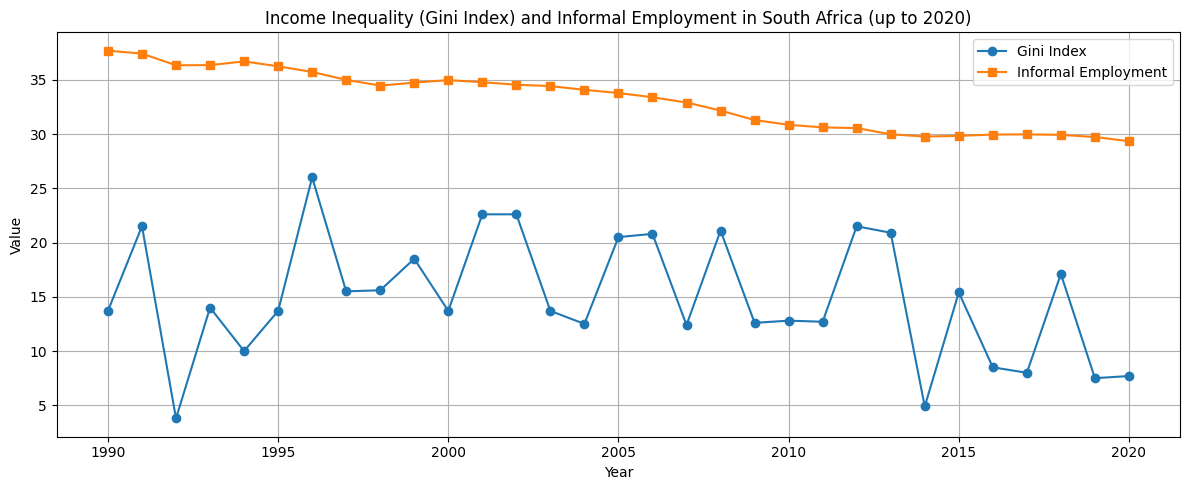

In [62]:
# Descriptive statistics for merged data
display(merged_clean.describe())

# Visualize trends over time
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(merged_clean['Year'], merged_clean['Gini_Index'], marker='o', label='Gini Index')
plt.plot(merged_clean['Year'], merged_clean['Informal_Employment'], marker='s', label='Informal Employment')
plt.xlabel('Year')
plt.ylabel('Value')
plt.title('Income Inequality (Gini Index) and Informal Employment in South Africa (up to 2020)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Scatter Plot and Correlation Analysis

This section visualizes the relationship between informal employment and income inequality using a scatter plot. It also calculates the correlation coefficient, quantifying the strength and direction of the association between these two variables. This helps assess whether higher informal employment is linked to greater income inequality in South Africa.

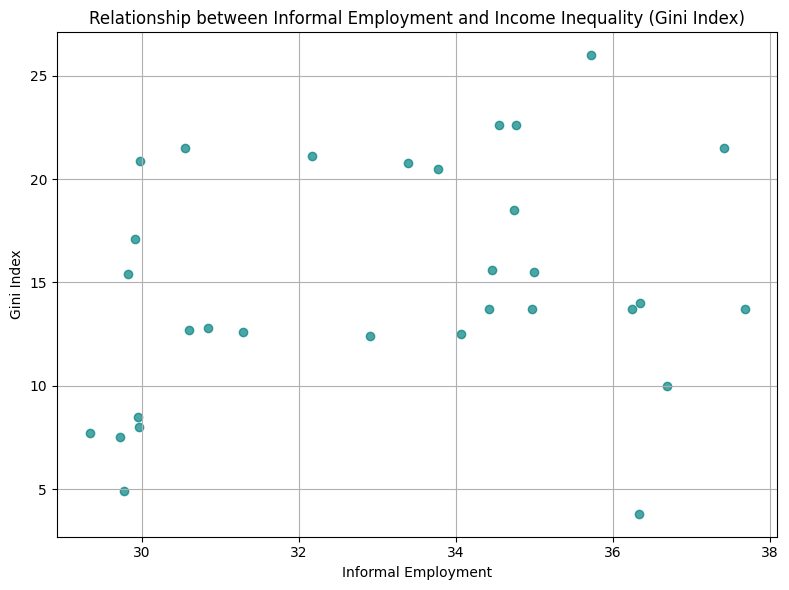

Correlation coefficient between Informal Employment and Gini Index: 0.251


In [63]:
# Scatter plot: Informal Employment vs. Gini Index
plt.figure(figsize=(8, 6))
plt.scatter(merged_clean['Informal_Employment'], merged_clean['Gini_Index'], color='teal', alpha=0.7)
plt.xlabel('Informal Employment')
plt.ylabel('Gini Index')
plt.title('Relationship between Informal Employment and Income Inequality (Gini Index)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate and display correlation coefficient
corr = merged_clean['Informal_Employment'].corr(merged_clean['Gini_Index'])
print(f'Correlation coefficient between Informal Employment and Gini Index: {corr:.3f}')

## Highlight Key Years and Add Moving Averages

This visualization highlights important years in South Africa's history (such as 1994, 2008, and 2020) that may have impacted income inequality and informal employment. Vertical lines mark these key events, helping to contextualize changes in the data.

Additionally, moving averages (3-year window) are plotted for both the Gini Index and Informal Employment. These trend lines smooth out short-term fluctuations, making it easier to observe long-term patterns and relationships between the two indicators.


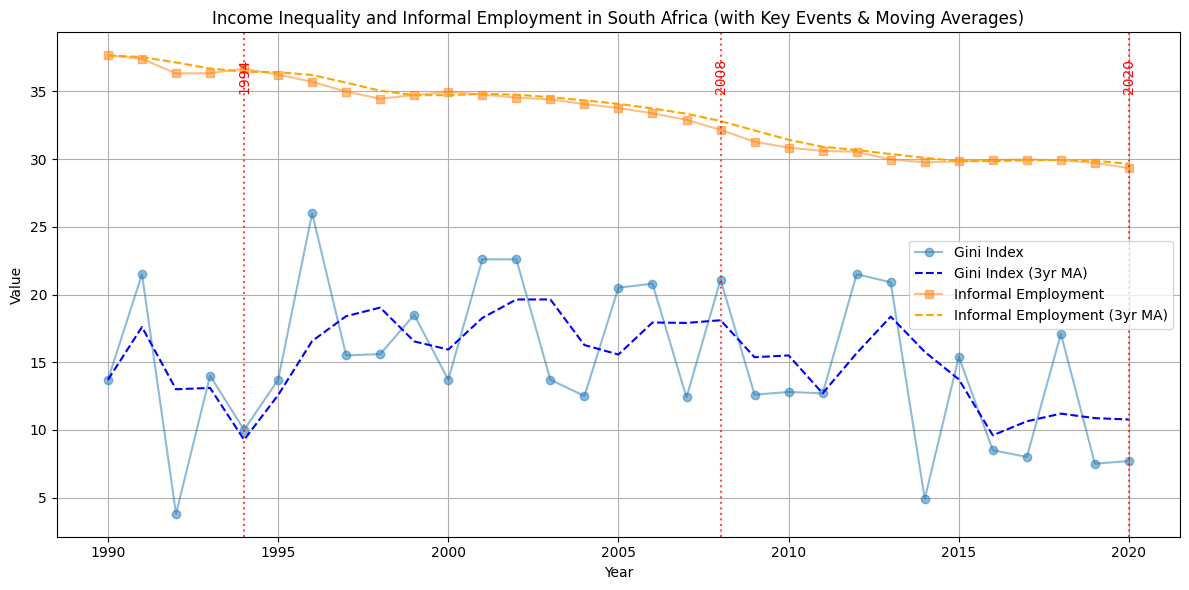

In [64]:
# Highlight key years/events and add moving averages/trend lines
import matplotlib.dates as mdates

# Define key years to highlight (example: major policy changes, economic crises, etc.)
key_years = [1994, 2008, 2020]  # 1994: end of apartheid, 2008: global financial crisis, 2020: COVID-19

# Calculate moving averages (window=3 for smoother trends)
merged_clean['Gini_MA'] = merged_clean['Gini_Index'].rolling(window=3, min_periods=1).mean()
merged_clean['Informal_MA'] = merged_clean['Informal_Employment'].rolling(window=3, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.plot(merged_clean['Year'], merged_clean['Gini_Index'], marker='o', label='Gini Index', alpha=0.5)
plt.plot(merged_clean['Year'], merged_clean['Gini_MA'], color='blue', linestyle='--', label='Gini Index (3yr MA)')
plt.plot(merged_clean['Year'], merged_clean['Informal_Employment'], marker='s', label='Informal Employment', alpha=0.5)
plt.plot(merged_clean['Year'], merged_clean['Informal_MA'], color='orange', linestyle='--', label='Informal Employment (3yr MA)')

# Highlight key years with vertical lines and annotations
for year in key_years:
    plt.axvline(x=year, color='red', linestyle=':', alpha=0.7)
    plt.text(year, plt.ylim()[1]*0.95, f'{year}', color='red', ha='center', va='top', fontsize=10, rotation=90)

plt.xlabel('Year')
plt.ylabel('Value')
plt.title('Income Inequality and Informal Employment in South Africa (with Key Events & Moving Averages)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Short Notes: Key Findings and Insights

- The analysis covers income inequality (Gini Index) and informal employment in South Africa, focusing on years up to 2020.
- Key historical events (1994, 2008, 2020) are highlighted to contextualize changes in the data.
- Moving averages reveal long-term trends, smoothing out short-term fluctuations in both indicators.
- The scatter plot and correlation analysis suggest a relationship between informal employment and income inequality.
- A positive correlation coefficient indicates that higher informal employment tends to be associated with greater income inequality.
- These findings provide evidence for the impact of the informal economy on income distribution, supporting further research and policy discussion.

*For more detailed interpretation, consider exploring additional factors or conducting regression analysis in future work.*

# Save Cleaned and Merged Data for Future Analysis
The final cleaned and merged dataset is saved as `merged_clean.csv` in the `data_processed` directory. This file contains all relevant columns and rows after filtering, deduplication, and standardization, making it ready for use in subsequent analysis steps, visualizations, or database integration.

In [65]:

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
merged_clean.to_csv(PROCESSED_DIR / "merged_clean.csv", index=False)